In [1]:
# ============================================
# 03 - Anomaly Detection with Isolation Forest
# Cell 1: Imports and load the clean dataset
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import precision_score, recall_score, f1_score, classification_report

import warnings
warnings.filterwarnings('ignore')

# Fixed seed for reproducibility (same as the LSTM notebook)
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Load the clean hourly dataset we created in notebook 01
df = pd.read_csv('../data/clean_hourly_power.csv', parse_dates=['datetime'], index_col='datetime')

print("Dataset loaded successfully!")
print(f"Shape: {df.shape[0]:,} rows x {df.shape[1]} columns")
print(f"Date range: {df.index.min()} -> {df.index.max()}")
print("\nColumns available:")
print(list(df.columns))
print("\nFirst few rows:")
df.head()

Dataset loaded successfully!
Shape: 34,589 rows x 7 columns
Date range: 2006-12-16 17:00:00 -> 2010-11-26 21:00:00

Columns available:
['Global_active_power', 'Global_reactive_power', 'Voltage', 'Global_intensity', 'Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3']

First few rows:


,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
datetime,,,,,,,
2006-12-16 17:00:00,4.222889,0.229000,234.643889,18.100000,0.0,0.527778,16.861111
2006-12-16 18:00:00,3.632200,0.080033,234.580167,15.600000,0.0,6.716667,16.866667
2006-12-16 19:00:00,3.400233,0.085233,233.232500,14.503333,0.0,1.433333,16.683333
2006-12-16 20:00:00,3.268567,0.075100,234.071500,13.916667,0.0,0.000000,16.783333
2006-12-16 21:00:00,3.056467,0.076667,237.158667,13.046667,0.0,0.416667,17.216667


In [2]:
# ============================================
# Cell 2: Feature selection, scaling, and fit Isolation Forest
# ============================================

# Features to monitor for anomalies (all meaningful signals).
# Voltage and reactive power are included because real anomalies often show
# up as an unusual COMBINATION of readings, not just high active power.
features = [
    'Global_active_power',
    'Global_reactive_power',
    'Voltage',
    'Global_intensity',
    'Sub_metering_1',
    'Sub_metering_2',
    'Sub_metering_3'
]

X = df[features].copy()
print(f"Feature matrix shape: {X.shape}")

# Standardise features (mean 0, std 1) so no single feature dominates
# purely because of its scale (e.g. Voltage ~240 vs reactive power ~0.1).
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# --- Isolation Forest ---
# contamination = expected proportion of anomalies. We set 1% as a sensible
# starting assumption for "unusual" hours; this is a tunable parameter.
CONTAMINATION = 0.01

iso_forest = IsolationForest(
    n_estimators=200,        # number of trees
    contamination=CONTAMINATION,
    max_samples='auto',
    random_state=RANDOM_STATE,
    n_jobs=-1                # use all CPU cores
)

# Fit and predict: returns +1 for normal, -1 for anomaly
iso_forest.fit(X_scaled)
predictions = iso_forest.predict(X_scaled)

# Anomaly score (lower = more anomalous)
scores = iso_forest.decision_function(X_scaled)

# Add results back to a working dataframe
results = df.copy()
results['anomaly_score'] = scores
results['is_anomaly'] = (predictions == -1).astype(int)

n_anomalies = results['is_anomaly'].sum()
print(f"\nIsolation Forest trained on {X.shape[0]:,} hourly records")
print(f"Contamination setting: {CONTAMINATION*100:.0f}%")
print(f"Anomalies detected: {n_anomalies:,} ({n_anomalies/len(results)*100:.2f}% of data)")
print(f"Normal points:      {len(results)-n_anomalies:,}")
print("\nMost anomalous hours (lowest scores):")
results.nsmallest(5, 'anomaly_score')[features + ['anomaly_score']]

Feature matrix shape: (34589, 7)

Isolation Forest trained on 34,589 hourly records
Contamination setting: 1%
Anomalies detected: 346 (1.00% of data)
Normal points:      34,243

Most anomalous hours (lowest scores):


,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,anomaly_score
datetime,,,,,,,,
2008-02-02 19:00:00,6.496033,0.427400,231.303333,28.200000,19.166667,30.700000,16.433333,-0.100874
2007-03-05 19:00:00,5.644900,0.359000,234.954000,24.116667,23.583333,25.600000,2.333333,-0.099817
2009-01-16 20:00:00,6.519633,0.431600,236.970167,27.746667,26.150000,28.200000,17.233333,-0.098178
2007-05-08 12:00:00,4.719133,0.490900,230.766167,20.713333,25.716667,23.233333,16.350000,-0.096915
2007-03-31 10:00:00,5.161067,0.519833,234.162333,22.243333,25.083333,26.300000,16.816667,-0.096048


In [3]:
# ============================================
# Cell 3: Z-score baseline + agreement comparison
# ============================================

# Because the dataset has no labelled anomalies, we build a transparent
# statistical baseline: flag any hour where Global_active_power is more than
# 3 standard deviations from the mean (the classic Z-score rule).

mean_power = df['Global_active_power'].mean()
std_power = df['Global_active_power'].std()
Z_THRESHOLD = 3.0

results['z_score'] = (df['Global_active_power'] - mean_power) / std_power
results['zscore_anomaly'] = (results['z_score'].abs() > Z_THRESHOLD).astype(int)

n_zscore = results['zscore_anomaly'].sum()

print("="*55)
print("   BASELINE: Z-SCORE THRESHOLD (|z| > 3)")
print("="*55)
print(f"   Mean active power: {mean_power:.3f} kW")
print(f"   Std deviation:     {std_power:.3f} kW")
print(f"   Threshold:         > {mean_power + Z_THRESHOLD*std_power:.3f} kW")
print(f"   Anomalies flagged: {n_zscore:,} ({n_zscore/len(results)*100:.2f}%)")
print("="*55)

# --- How much do the two methods agree? ---
both      = ((results['is_anomaly']==1) & (results['zscore_anomaly']==1)).sum()
iso_only  = ((results['is_anomaly']==1) & (results['zscore_anomaly']==0)).sum()
z_only    = ((results['is_anomaly']==0) & (results['zscore_anomaly']==1)).sum()

print("\n" + "="*55)
print("   METHOD COMPARISON")
print("="*55)
print(f"   Isolation Forest flagged:  {results['is_anomaly'].sum():,}")
print(f"   Z-score baseline flagged:  {n_zscore:,}")
print(f"   Flagged by BOTH:           {both:,}")
print(f"   Isolation Forest ONLY:     {iso_only:,}")
print(f"   Z-score ONLY:              {z_only:,}")
print("="*55)
print("\n   Interpretation:")
print("   - 'Both' = clear anomalies both methods agree on.")
print("   - 'Isolation Forest only' = multivariate anomalies the simple")
print("     Z-score rule MISSES (e.g. odd voltage/sub-meter combinations")
print("     without extreme total power). This is the IF's added value.")
print("   - 'Z-score only' = single-feature spikes IF treated as normal in")
print("     the wider multivariate context.")

# Treat the Z-score flags as a proxy reference to score the IF against it
y_proxy = results['zscore_anomaly'].values
y_pred  = results['is_anomaly'].values

precision = precision_score(y_proxy, y_pred)
recall    = recall_score(y_proxy, y_pred)
f1        = f1_score(y_proxy, y_pred)

print("\n" + "="*55)
print("   ISOLATION FOREST vs Z-SCORE PROXY REFERENCE")
print("="*55)
print(f"   Precision: {precision:.4f}")
print(f"   Recall:    {recall:.4f}")
print(f"   F1-score:  {f1:.4f}")
print("="*55)

   BASELINE: Z-SCORE THRESHOLD (|z| > 3)
   Mean active power: 1.086 kW
   Std deviation:     0.895 kW
   Threshold:         > 3.771 kW
   Anomalies flagged: 440 (1.27%)

   METHOD COMPARISON
   Isolation Forest flagged:  346
   Z-score baseline flagged:  440
   Flagged by BOTH:           267
   Isolation Forest ONLY:     79
   Z-score ONLY:              173

   Interpretation:
   - 'Both' = clear anomalies both methods agree on.
   - 'Isolation Forest only' = multivariate anomalies the simple
     Z-score rule MISSES (e.g. odd voltage/sub-meter combinations
     without extreme total power). This is the IF's added value.
   - 'Z-score only' = single-feature spikes IF treated as normal in
     the wider multivariate context.

   ISOLATION FOREST vs Z-SCORE PROXY REFERENCE
   Precision: 0.7717
   Recall:    0.6068
   F1-score:  0.6794


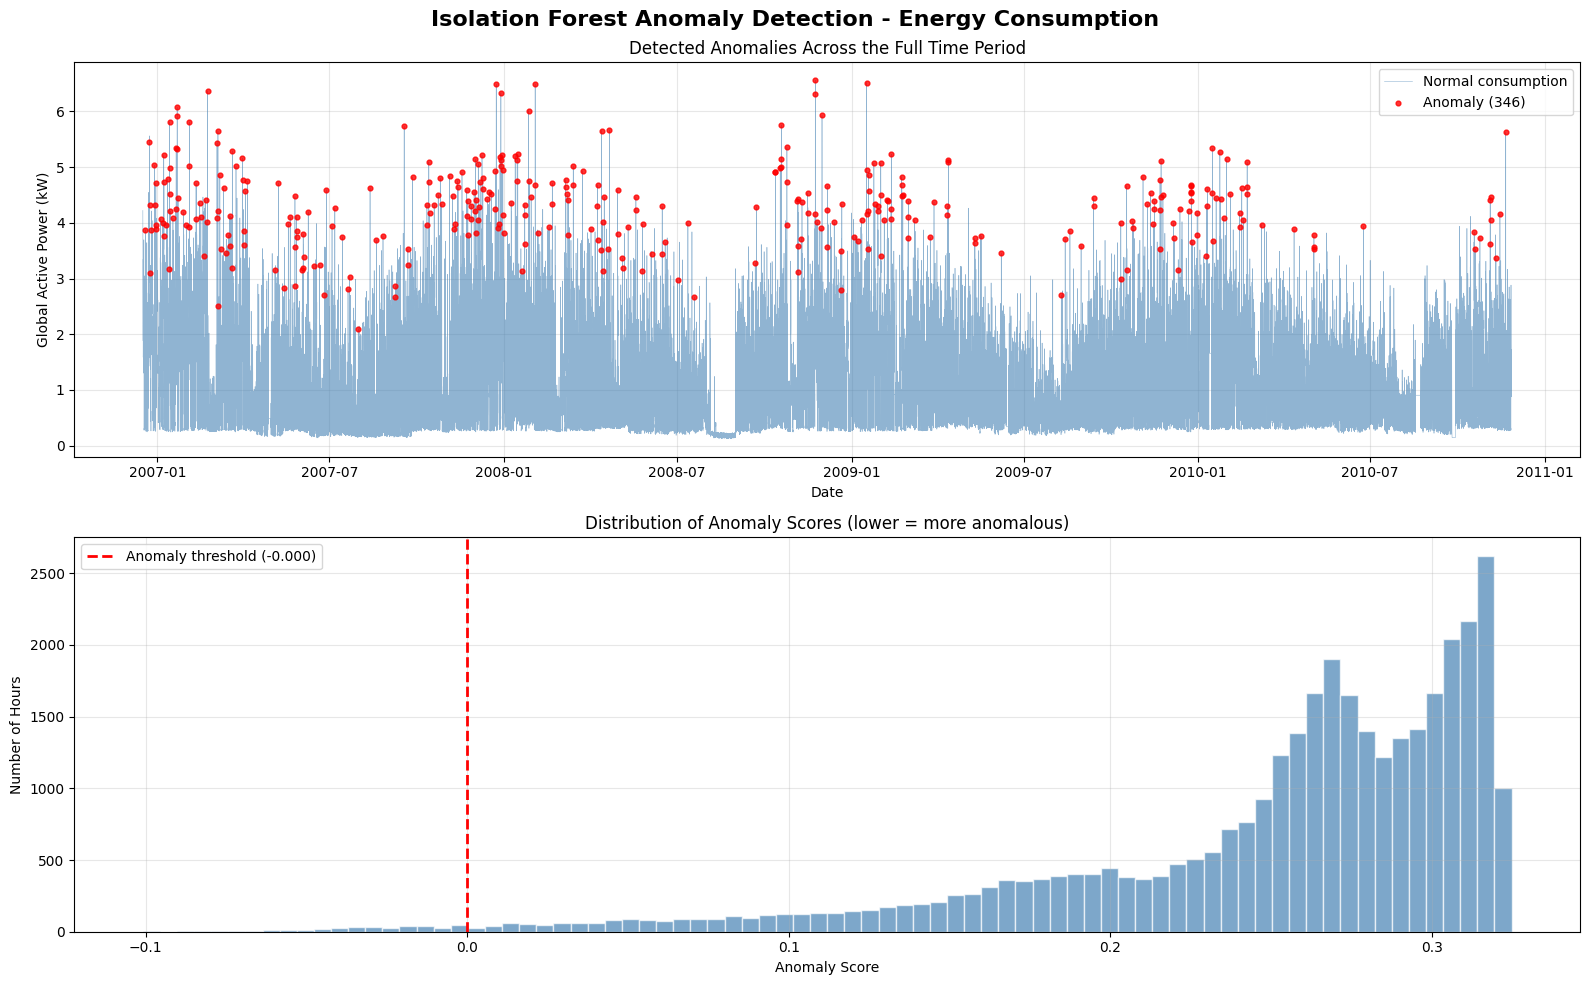


Anomaly detection graph saved to results/05_anomaly_detection.png


In [4]:
# ============================================
# Cell 4: Visualise the detected anomalies
# ============================================

fig, axes = plt.subplots(2, 1, figsize=(16, 10))
fig.suptitle('Isolation Forest Anomaly Detection - Energy Consumption',
             fontsize=16, fontweight='bold')

# --- Plot 1: Full time series with anomalies marked ---
normal = results[results['is_anomaly'] == 0]
anomalies = results[results['is_anomaly'] == 1]

axes[0].plot(results.index, results['Global_active_power'],
             color='steelblue', linewidth=0.4, alpha=0.6, label='Normal consumption')
axes[0].scatter(anomalies.index, anomalies['Global_active_power'],
                color='red', s=12, alpha=0.8, label=f'Anomaly ({len(anomalies)})', zorder=5)
axes[0].set_title('Detected Anomalies Across the Full Time Period')
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Global Active Power (kW)')
axes[0].legend(loc='upper right')
axes[0].grid(True, alpha=0.3)

# --- Plot 2: Anomaly score distribution ---
axes[1].hist(results['anomaly_score'], bins=80, color='steelblue',
             alpha=0.7, edgecolor='white')
threshold_score = results[results['is_anomaly'] == 1]['anomaly_score'].max()
axes[1].axvline(threshold_score, color='red', linestyle='--', linewidth=2,
                label=f'Anomaly threshold ({threshold_score:.3f})')
axes[1].set_title('Distribution of Anomaly Scores (lower = more anomalous)')
axes[1].set_xlabel('Anomaly Score')
axes[1].set_ylabel('Number of Hours')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()

# Save to results folder for the dissertation
import os
os.makedirs('../results', exist_ok=True)
plt.savefig('../results/05_anomaly_detection.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nAnomaly detection graph saved to results/05_anomaly_detection.png")

In [5]:
# ============================================
# Cell 5: Save results to CSV for the dissertation
# ============================================

# 1. Save the anomalies themselves (for the appendix / inspection)
anomaly_export = results[results['is_anomaly'] == 1][
    features + ['anomaly_score', 'z_score']
].sort_values('anomaly_score')
anomaly_export.to_csv('../results/detected_anomalies.csv')
print(f"Saved {len(anomaly_export):,} detected anomalies to results/detected_anomalies.csv")

# 2. Save a summary comparison table (Isolation Forest vs Z-score baseline)
summary = pd.DataFrame({
    'Method': ['Isolation Forest (multivariate)', 'Z-score baseline (univariate)'],
    'Anomalies_Flagged': [results['is_anomaly'].sum(), results['zscore_anomaly'].sum()],
    'Percentage': [
        f"{results['is_anomaly'].sum()/len(results)*100:.2f}%",
        f"{results['zscore_anomaly'].sum()/len(results)*100:.2f}%"
    ],
    'Features_Used': [7, 1]
})
summary.to_csv('../results/anomaly_method_comparison.csv', index=False)
print("\nSaved method comparison to results/anomaly_method_comparison.csv")
print(summary.to_string(index=False))

# 3. Print the headline numbers for your dissertation Results chapter
print("\n" + "="*55)
print("   ANOMALY DETECTION - KEY RESULTS SUMMARY")
print("="*55)
print(f"   Dataset:                 34,589 hourly records")
print(f"   Features monitored:      7 (power, voltage, intensity, sub-meters)")
print(f"   Model:                   Isolation Forest (200 trees)")
print(f"   Anomalies detected:      {results['is_anomaly'].sum():,} (1.00%)")
print(f"   Agreement with baseline: F1 = {f1:.4f}")
print(f"   Multivariate-only finds: {iso_only} hours the Z-score rule missed")
print("="*55)
print("\nAll anomaly detection results saved successfully!")

Saved 346 detected anomalies to results/detected_anomalies.csv

Saved method comparison to results/anomaly_method_comparison.csv
                         Method  Anomalies_Flagged Percentage  Features_Used
Isolation Forest (multivariate)                346      1.00%              7
  Z-score baseline (univariate)                440      1.27%              1

   ANOMALY DETECTION - KEY RESULTS SUMMARY
   Dataset:                 34,589 hourly records
   Features monitored:      7 (power, voltage, intensity, sub-meters)
   Model:                   Isolation Forest (200 trees)
   Anomalies detected:      346 (1.00%)
   Agreement with baseline: F1 = 0.6794
   Multivariate-only finds: 79 hours the Z-score rule missed

All anomaly detection results saved successfully!
